In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math
import random

from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.trainers import WordLevelTrainer
from tokenizers.pre_tokenizers import Whitespace

In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device.type} device")

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

Using cuda device


In [4]:
# ===============================
# LOAD DATASET (WIKITEXT-2)
# ===============================
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

train_text = dataset["train"]["text"] # List of Strings 
test_text  = dataset["test"]["text"] # List of Strings


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

In [5]:
# ===============================
# TOKENIZER (WORD LEVEL)
# ===============================
import os

if os.path.exists("tokenizer.json"):
    tokenizer = Tokenizer.from_file("tokenizer.json")
    print("already exist")
else:
    tokenizer = Tokenizer(WordLevel(unk_token="<unk>"))
    tokenizer.pre_tokenizer = Whitespace()
    trainer = WordLevelTrainer(
        min_frequency=1,
        special_tokens=["<pad>", "<unk>"]
    )
    tokenizer.train_from_iterator(train_text, trainer)
    tokenizer.save("tokenizer.json")
    "created new "

pad_idx = tokenizer.token_to_id("<pad>")
unk_idx = tokenizer.token_to_id("<unk>")


# SAFETY CHECKS 
assert tokenizer.token_to_id("<unk>") is not None, "UNK token missing!"
assert tokenizer.token_to_id("<pad>") is not None, "PAD token missing!"

vocab_size = tokenizer.get_vocab_size() 
vocab_size

30000

In [6]:
# ===============================
# ENCODE TEXT
# ===============================
def encode_text(text_list, tokenizer):
    ids = []
    for line in text_list:
        enc = tokenizer.encode(line)
        ids.extend(enc.ids)
    return torch.tensor(ids, dtype=torch.long)

train_data = encode_text(train_text, tokenizer)
test_data  = encode_text(test_text, tokenizer)
len(train_data) , len(test_data)

(2074935, 243524)

In [7]:
# ===============================
# DATASET CLASS
# ===============================
sequence_length = 60
batch_size = 128

class LanguageModelDataset(Dataset):
    def __init__(self, data, seq_length):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_length]
        y = self.data[idx+1:idx+self.seq_length+1]
        return x, y

train_dataset = LanguageModelDataset(train_data, sequence_length)
test_dataset  = LanguageModelDataset(test_data, sequence_length)

train_loader = DataLoader(train_dataset, batch_size=batch_size,shuffle=False,drop_last=True,num_workers=2, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,num_workers =2,  pin_memory=True, persistent_workers=True)

In [8]:
# ===============================
# MODEL: LSTM LANGUAGE MODEL
# ===============================
class RNNLanguageModel(nn.Module):
    def __init__(self, vocab_size, rnn_type="lstm", embed_dim=256, hidden_size=128, num_layers=2 ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        if rnn_type == "lstm":
            self.rnn = nn.LSTM(
                embed_dim, hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=0.3
            )
        elif rnn_type == "gru":
            self.rnn = nn.GRU(
                embed_dim, hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=0.3
            )
        else:
            raise ValueError("Invalid rnn_type")

        self.fc = nn.Linear(hidden_size, vocab_size)
        self.rnn_type = rnn_type

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.rnn(x, hidden)
        logits = self.fc(out)
        return logits, hidden


In [9]:
# ===============================
# TRAIN FUNCTION
# ===============================
def train(dataloader, model, loss_fn, optimizer, device):
    model.train()
    total_loss = 0.0
    hidden = None  # initialize once per epoch

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()

        logits, hidden = model(X, hidden)

        # DETACH hidden state to prevent backprop through entire history
        if isinstance(hidden, tuple):  # LSTM
            hidden = tuple(h.detach() for h in hidden)
        else:  # GRU
            hidden = hidden.detach()

        loss = loss_fn(
            logits.view(-1, logits.size(-1)),
            y.view(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

        if batch == 0:
            print(f"loss: {loss.item():.4f}")

    avg_loss = total_loss / len(dataloader)
    perplexity = math.exp(min(avg_loss, 20))

    return avg_loss, perplexity


In [10]:
# ===============================
# TEST FUNCTION
# ===============================
def test(dataloader, model, loss_fn, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for X, y in dataloader:
            hidden = None   # ✅ RESET EVERY BATCH

            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits, _ = model(X, hidden)

            loss = loss_fn(
                logits.view(-1, logits.size(-1)),
                y.view(-1)
            )

            total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    perplexity = math.exp(min(avg_loss, 20))

    print(
        f"Test Metrics:\n"
        f" Perplexity: {perplexity:.2f}\n"
        f" Avg loss: {avg_loss:.4f}"
    )

    return avg_loss, perplexity



In [11]:
def sample_from_logits(logits, temperature=1.0):
    logits = logits / temperature
    probs = torch.softmax(logits, dim=-1)
    return torch.multinomial(probs, num_samples=1).item()

In [12]:
def generate_text(
    model,
    tokenizer,
    prompt,
    max_new_tokens=50,
    temperature=1.0,
    device="cuda"
):
    model.eval()

    encoded = tokenizer.encode(prompt)
    input_ids = torch.tensor(encoded.ids, dtype=torch.long).unsqueeze(0).to(device)

    generated = encoded.ids.copy()
    hidden = None

    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits, hidden = model(input_ids, hidden)

            next_token_logits = logits[:, -1, :]
            next_token = sample_from_logits(
                next_token_logits.squeeze(0),
                temperature
            )

            generated.append(next_token)

            input_ids = torch.cat(
                [input_ids, torch.tensor([[next_token]], device=device)],
                dim=1
            )

            if input_ids.size(1) > sequence_length:
                input_ids = input_ids[:, -sequence_length:]

    return tokenizer.decode(generated)

In [13]:
# ===============================
# TRAINING LOOP
# ===============================
epochs = 20
lr = 3e-4

patience = 2          # how many epochs to wait
min_delta = 0.0       # minimum improvement to count
epochs_no_improve = 0
best_ppl = float("inf")

model = RNNLanguageModel(vocab_size, rnn_type="lstm").to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss(ignore_index=pad_idx)

train_losses, train_ppls = [], []
test_losses, test_ppls = [], []

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}\n-------------------------------")

    # 1️⃣ Train for one epoch
    tr_loss, tr_ppl = train(train_loader, model, loss_fn, optimizer, device)

    # 2️⃣ Validate / Test
    te_loss, te_ppl = test(test_loader, model, loss_fn, device)

    train_losses.append(tr_loss)
    train_ppls.append(tr_ppl)
    test_losses.append(te_loss)
    test_ppls.append(te_ppl)

    # 3️⃣ Early Stopping Logic (LIVES HERE)
    if te_ppl < best_ppl - min_delta:
        best_ppl = te_ppl
        epochs_no_improve = 0
        torch.save(model.state_dict(), "LSTM_WikiText2.pth")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print("⏹ Early stopping triggered.")
        break

print("Training Complete")




Epoch 1
-------------------------------
loss: 10.3049
Test Metrics:
 Perplexity: 325.06
 Avg loss: 5.7840

Epoch 2
-------------------------------
loss: 6.2861
Test Metrics:
 Perplexity: 267.69
 Avg loss: 5.5898

Epoch 3
-------------------------------
loss: 6.0240
Test Metrics:
 Perplexity: 239.32
 Avg loss: 5.4778

Epoch 4
-------------------------------
loss: 5.8168
Test Metrics:
 Perplexity: 224.06
 Avg loss: 5.4119

Epoch 5
-------------------------------
loss: 5.7514
Test Metrics:
 Perplexity: 217.43
 Avg loss: 5.3819

Epoch 6
-------------------------------
loss: 5.6388
Test Metrics:
 Perplexity: 211.58
 Avg loss: 5.3546

Epoch 7
-------------------------------
loss: 5.5695
Test Metrics:
 Perplexity: 204.18
 Avg loss: 5.3190

Epoch 8
-------------------------------
loss: 5.5123
Test Metrics:
 Perplexity: 203.26
 Avg loss: 5.3145

Epoch 9
-------------------------------
loss: 5.4391
Test Metrics:
 Perplexity: 198.54
 Avg loss: 5.2910

Epoch 10
-------------------------------
los

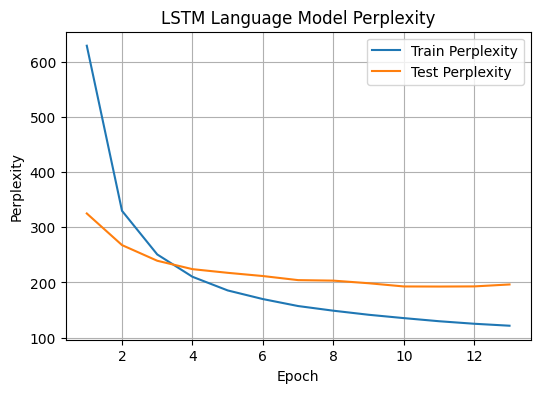

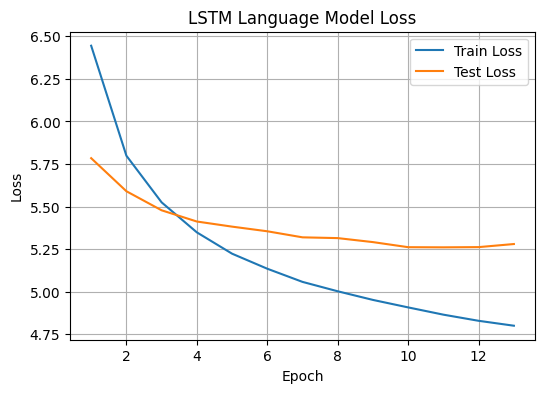

In [14]:
# ===============================
# PLOTTING
# ===============================
from matplotlib import pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs_range, train_ppls, label="Train Perplexity")
plt.plot(epochs_range, test_ppls, label="Test Perplexity")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("LSTM Language Model Perplexity")
plt.legend()
plt.grid(True)

plt.figure(figsize=(6,4))
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Language Model Loss")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
from tokenizers import Tokenizer
tokenizer = Tokenizer.from_file("tokenizer.json")

In [16]:
model_lstm = RNNLanguageModel(vocab_size, rnn_type="lstm").to(device)
model_lstm.load_state_dict(torch.load("LSTM_WikiText2.pth", map_location=device))
model_lstm.eval()


RNNLanguageModel(
  (embedding): Embedding(30000, 256)
  (rnn): LSTM(256, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=30000, bias=True)
)

In [17]:
prompt = "The meaning of life is"
print(generate_text(
    model_lstm,
    tokenizer,
    prompt,
    max_new_tokens=100,
    temperature=0.8,
    device=device
))

The meaning of life is known as the @-@ , which forms a common camera between 19 and ; in the , the 7th century District has more than the starter . A few hours each other and a minor number of common starlings can be commonplace . The tower is adaptations of boxes by birds , in particular , and a EU ) . Curtis is more common than a common conductor Vocal transcend the bathing , and the mammalian incident can be initially still provide occurred on 23 June 2012 . It was introduced on August 2


In [18]:
# ===============================
# TRAINING LOOP
# ===============================
epochs = 20
lr = 3e-4

patience = 2          # how many epochs to wait
min_delta = 0.0       # minimum improvement to count
epochs_no_improve = 0
best_ppl = float("inf")

model = RNNLanguageModel(vocab_size, rnn_type="gru").to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss(ignore_index=pad_idx)

train_losses, train_ppls = [], []
test_losses, test_ppls = [], []

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}\n-------------------------------")

    # 1️⃣ Train for one epoch
    tr_loss, tr_ppl = train(train_loader, model, loss_fn, optimizer, device)

    # 2️⃣ Validate / Test
    te_loss, te_ppl = test(test_loader, model, loss_fn, device)

    train_losses.append(tr_loss)
    train_ppls.append(tr_ppl)
    test_losses.append(te_loss)
    test_ppls.append(te_ppl)

    # 3️⃣ Early Stopping Logic (LIVES HERE)
    if te_ppl < best_ppl - min_delta:
        best_ppl = te_ppl
        epochs_no_improve = 0
        torch.save(model.state_dict(), "GRU_WikiText2.pth")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print("⏹ Early stopping triggered.")
        break

print("Training Complete")




Epoch 1
-------------------------------
loss: 10.3301
Test Metrics:
 Perplexity: 301.83
 Avg loss: 5.7099

Epoch 2
-------------------------------
loss: 6.3635
Test Metrics:
 Perplexity: 244.76
 Avg loss: 5.5003

Epoch 3
-------------------------------
loss: 6.1241
Test Metrics:
 Perplexity: 220.72
 Avg loss: 5.3969

Epoch 4
-------------------------------
loss: 5.9247
Test Metrics:
 Perplexity: 208.65
 Avg loss: 5.3407

Epoch 5
-------------------------------
loss: 5.7886
Test Metrics:
 Perplexity: 201.48
 Avg loss: 5.3057

Epoch 6
-------------------------------
loss: 5.6744
Test Metrics:
 Perplexity: 195.10
 Avg loss: 5.2735

Epoch 7
-------------------------------
loss: 5.5863
Test Metrics:
 Perplexity: 189.46
 Avg loss: 5.2442

Epoch 8
-------------------------------
loss: 5.5160
Test Metrics:
 Perplexity: 186.40
 Avg loss: 5.2279

Epoch 9
-------------------------------
loss: 5.4609
Test Metrics:
 Perplexity: 185.04
 Avg loss: 5.2206

Epoch 10
-------------------------------
los

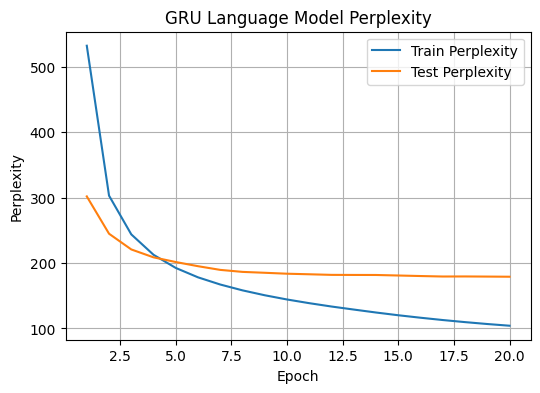

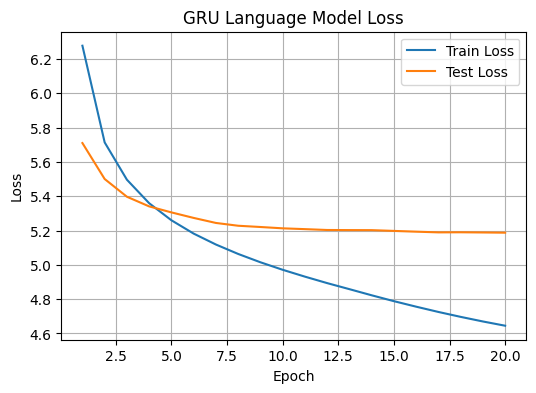

In [19]:
# ===============================
# PLOTTING
# ===============================
from matplotlib import pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs_range, train_ppls, label="Train Perplexity")
plt.plot(epochs_range, test_ppls, label="Test Perplexity")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("GRU Language Model Perplexity")
plt.legend()
plt.grid(True)

plt.figure(figsize=(6,4))
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Language Model Loss")
plt.legend()
plt.grid(True)

plt.show()

In [20]:
model_gru = RNNLanguageModel(vocab_size, rnn_type="gru").to(device)
model_gru.load_state_dict(torch.load("GRU_WikiText2.pth", map_location=device))
model_gru.eval()

RNNLanguageModel(
  (embedding): Embedding(30000, 256)
  (rnn): GRU(256, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=30000, bias=True)
)

In [21]:
prompt = "The meaning of life is"
print(generate_text(
    model_gru,
    tokenizer,
    prompt,
    max_new_tokens=100,
    temperature=0.8,
    device=device
))

The meaning of life is , the ground and three other species are not bird . Like the product , a common starling may be subsequently used for the , or in starlings such as the common starling . In Where he is thought to have been completely for the , and this behaviour is mentioned as as a common role for a nest . = = = Breeding = = = = = = = = = = = recordings = = = Japan is dedicated in his review of Alkan ' s work as its common person in Latin
